In [4]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
import astropy.units as u
from astropy.io import fits
from pathlib import Path
from IPython.display import clear_output
from importlib import reload
from datetime import datetime
today = int(datetime.today().strftime('%Y%m%d'))

import poppy
from poppy.poppy_core import PlaneType

import logging, sys
poppy_log = logging.getLogger('poppy')
poppy_log.setLevel('DEBUG')
logging.basicConfig(stream=sys.stdout, level=logging.INFO)
poppy_log.disabled = True

import esc_fresnel
import esc_fresnel.utils as utils
from esc_fresnel.math_module import xp, xcipy, ensure_np_array
from esc_fresnel.imshows import imshow1, imshow2, imshow3
import esc_fresnel.esc_fresnel as esc
import esc_fresnel.dm as dm
import esc_fresnel.esc_optics as esc_optics

dm_flat = utils.load_fits('../data/esc_fresnel_dm_flat.fits')


In [12]:
amp_dir = '/npool/nvme/kianmilani/esc-wfe-maps/reflectivity_maps_2024_09_15/'
opd_dir = '/npool/nvme/kianmilani/esc-wfe-maps/6nm_surfPSD/'

wfe_optic = 12

# Ignore OAP7 So that doesn't add any WFE when we compute the flat
opd_rms_vals = {
    'm1': 2*21*u.nm, 
    'm2': 2*8*u.nm, 
    'm3': 2*6*u.nm, 
    'm4': 2*12*u.nm, 
    'oap1': wfe_optic*u.nm,
    'fm1': wfe_optic*u.nm, 
    'oap2': wfe_optic*u.nm, 
    'oap3': wfe_optic*u.nm, 
    'fsm': wfe_optic*u.nm, 
    'fm2': wfe_optic*u.nm, 
    'oap4': wfe_optic*u.nm, 
    'oap5': wfe_optic*u.nm, 
    'input_lp': wfe_optic*u.nm, 
    'input_qwp': wfe_optic*u.nm, 
    'oap6': wfe_optic*u.nm, 
    'oap7': wfe_optic*u.nm, 
    'oap9': wfe_optic*u.nm, 
    'collimator': wfe_optic*u.nm, 
    'filter': wfe_optic*u.nm, 
    'output_qwp': wfe_optic*u.nm,
    'output_lp': wfe_optic*u.nm, 
    'oap10': wfe_optic*u.nm, 
}

wfes = {}
for optic in opd_rms_vals.keys():
    wfe = poppy.FITSOpticalElement(
        opd=opd_dir + f'{optic}_subap.fits', 
        opdunits='nanometers',
        transmission=amp_dir + f'{optic}_amp_subap_1000px.fits',
        name=f'{optic}_wfe',
        planetype=poppy.poppy_core.PlaneType.intermediate,
    )
    wfes[optic] = wfe


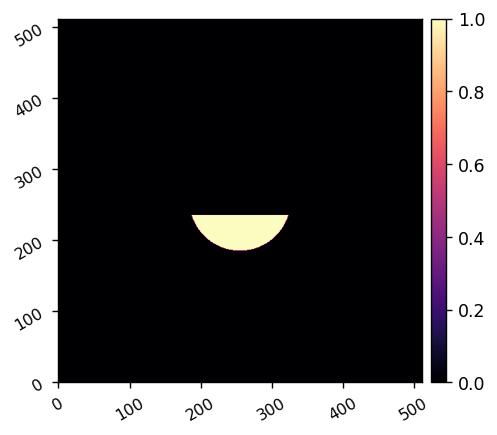

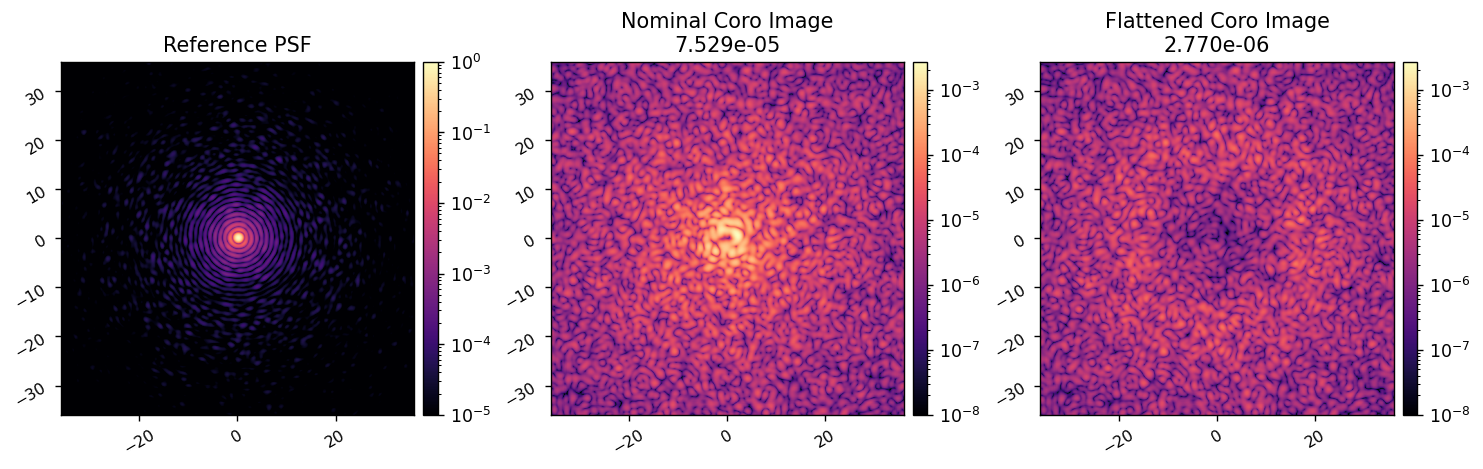

In [15]:
reload(esc)
M = esc.single(
    dm_ref=dm_flat,
)
M.wfes = wfes
M.npsf = 512

M.use_vortex = False
ref_psf = M.snap()
M.Imax_ref = xp.max(ref_psf)

M.use_vortex = True
M.zero_dm()
coro_im_0 = M.snap()

M.reset_dm()
coro_im_flat = M.snap()

coro_mask = utils.create_annular_focal_plane_mask(
    M.npsf,
    M.psf_pixelscale_lamD,
    irad=3, 
    orad=10,
    edge=3,
    rotation=90,
)
imshow1(coro_mask)

contrast_0 = utils.mean(coro_im_0, coro_mask)
contrast_flat = utils.mean(coro_im_flat, coro_mask)

imshow3(
    ref_psf/M.Imax_ref, coro_im_0, coro_im_flat,
    # ref_psf/M.Imax_ref, coro_im_0*coro_mask, coro_im_flat*coro_mask,
    f'Reference PSF',
    f'Nominal Coro Image\n{contrast_0:.3e}',
    f'Flattened Coro Image\n{contrast_flat:.3e}',
    lognorm=1,
    pxscl=M.psf_pixelscale_lamD,
    vmin1=1e-5, 
    vmin2=1e-8, vmax2=np.max(coro_im_0),
    vmin3=1e-8, vmax3=np.max(coro_im_0),
)

In [84]:
poppy_log.disabled = False

im = M.snap()

INFO:poppy:Initialized OpticalSystem: ESC to FPM
INFO:poppy:Added optic: Entrance Pupil (subaperture) after separation: 0.00e+00 m 
INFO:poppy:Added optic: Dummy Pupil OPD after separation: 0.00e+00 m 
INFO:poppy:Added optic: m1 after separation: 0.00e+00 m 
INFO:poppy:Added optic: m1_wfe after separation: 0.00e+00 m 
INFO:poppy:Added optic: m2 after separation: 7.50e+03 mm 
INFO:poppy:Added optic: m2_wfe after separation: 0.00e+00 m 
INFO:poppy:Added optic: m3 after separation: 7.44e+03 mm 
INFO:poppy:Added optic: m3_wfe after separation: 0.00e+00 m 
INFO:poppy:Added optic: m4 (pupil) after separation: 1.05e+03 mm 
INFO:poppy:Added optic: m4_wfe after separation: 0.00e+00 m 
INFO:poppy:Added optic: WCC_FP after separation: 1.27e+03 mm 
INFO:poppy:Added optic: oap1 after separation: 5.11e+02 mm 
INFO:poppy:Added optic: oap1_wfe after separation: 0.00e+00 m 
INFO:poppy:Added optic: fm1 after separation: 1.91e+02 mm 
INFO:poppy:Added optic: fm1_wfe after separation: 0.00e+00 m 
INFO:popp

In [90]:
reload(lina)
poke_amp = 1e-9
poke_modes = lina.utils.create_all_poke_modes(M.dm_mask)



Calculating Jacobian: 
	Calculated response for mode 952/952. Elapsed time=606.213 sec.
Jacobian built in 606.213 sec


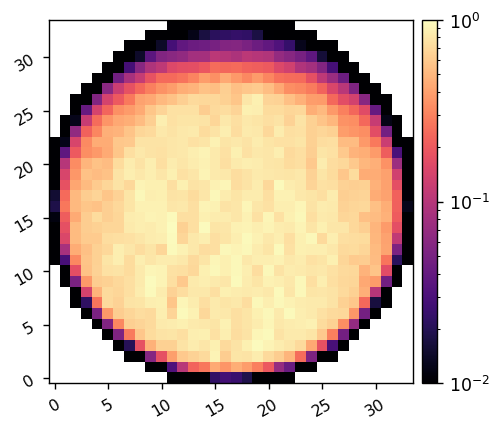

In [91]:
reload(lina.efc)

jac, response_cube = lina.efc.calibrate(M,
                                        poke_modes,
                                        #  poke_modes[800:951], 
                                        poke_amp,
                                        control_mask, 
                                        plot=True,
                                        return_all=True
                                        )

In [19]:
lina.utils.save_fits(f'../data/{today}_esc_fresnel_efc_cube.fits', response_cube)

Saved data to:  ../data/20240930_esc_fresnel_efc_cube.fits


In [92]:
M.zero_dm()
all_ims = []
all_efs = []
all_commands = []



Beginning closed-loop EFC.
	Closed-loop iteration 25 / 27
Using model to compute electric field


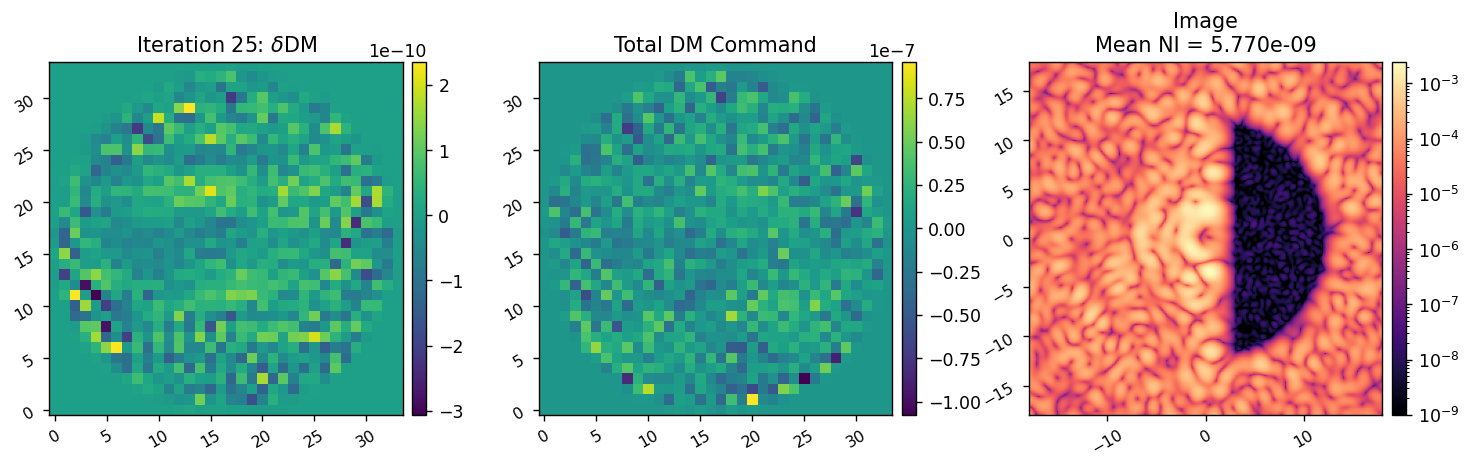

	Closed-loop iteration 26 / 27
Using model to compute electric field


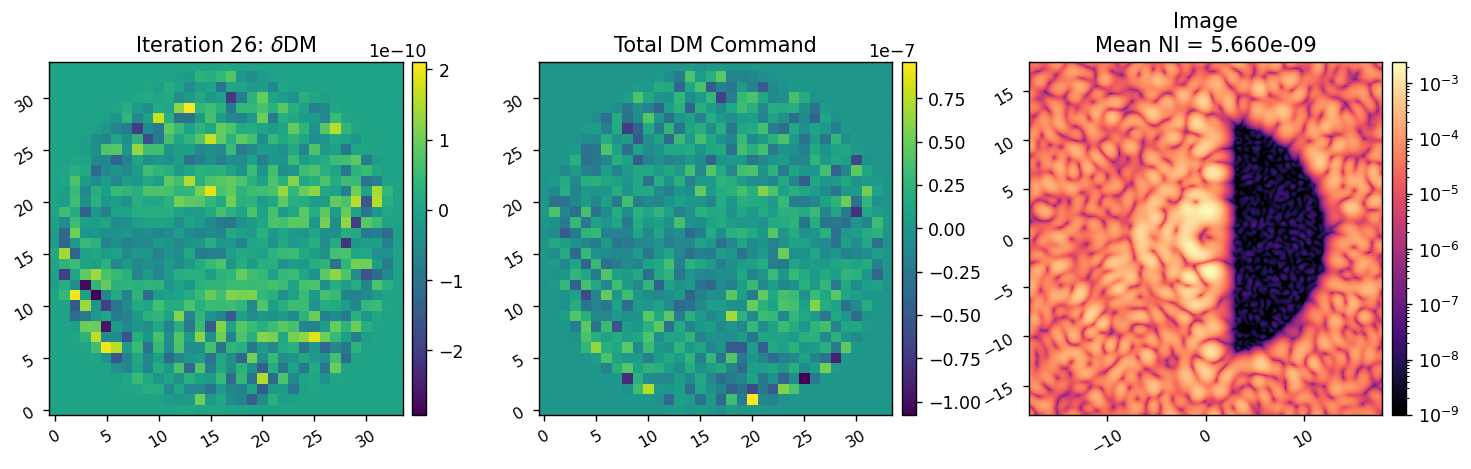

	Closed-loop iteration 27 / 27
Using model to compute electric field


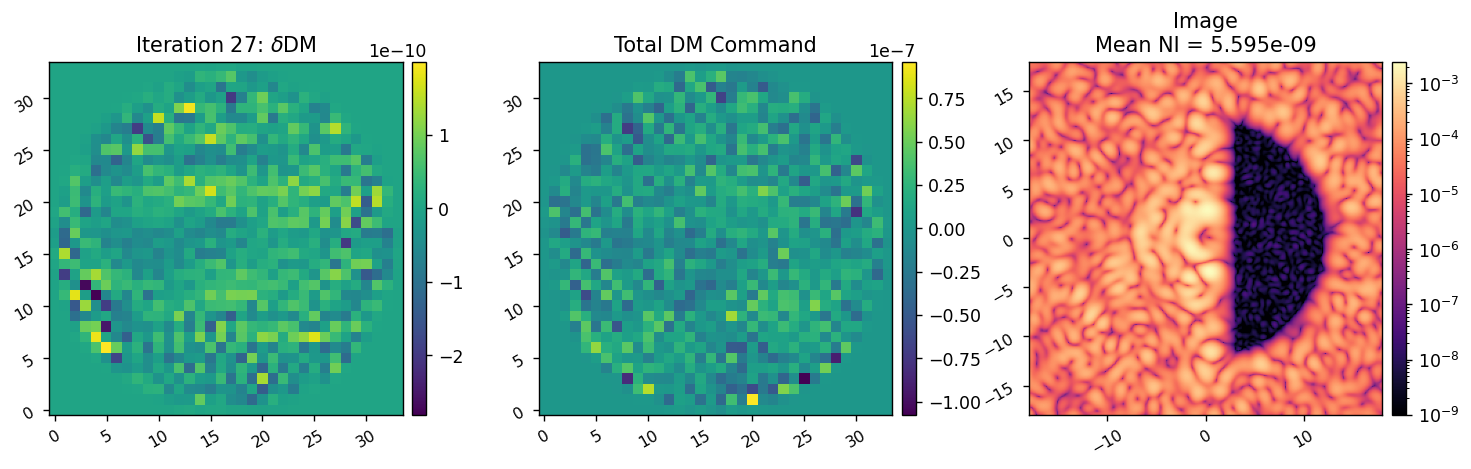

EFC completed in 4.241 sec.


In [101]:
reload(lina.efc)

control_matrix = lina.utils.beta_reg(jac, -2.5)
# control_matrix = lina.utils.beta_reg(jac, -5)

images, fields, dm_commands = lina.efc.run(M,
                                            control_matrix,
                                            poke_modes,
                                            control_mask, 
                                            # est_fun=est_fun,
                                            # est_params=est_params,
                                            loop_gain=0.5, 
                                            leakage=0.0,
                                            iterations=3, 
                                            plot_all=True, 
                                            plot_sms=False,
                                            plot_radial_contrast=False,
                                            all_ims=all_ims,
                                            all_efs=all_efs,
                                            all_commands=all_commands,
                                            )

Calculating Jacobian: 
	Calculated response for mode 952/952. Elapsed time=608.433 sec.
Jacobian built in 608.433 sec


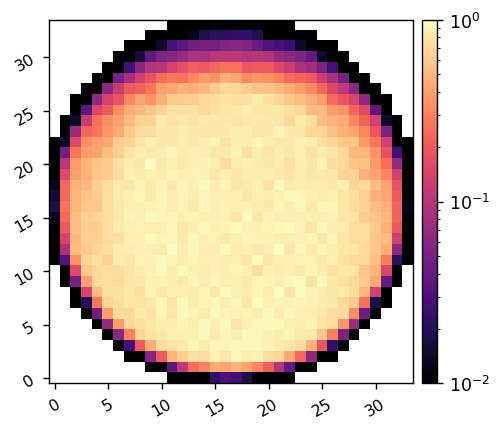

In [102]:
reload(lina.efc)
jac_2, response_cube_2 = lina.efc.calibrate(M,
                                            poke_modes,
                                            #  poke_modes[800:951], 
                                            poke_amp,
                                            control_mask, 
                                            plot=True,
                                            return_all=True
                                            )

In [29]:
lina.utils.save_fits(f'../data/{today}_esc_fresnel_efc_cube_2.fits', response_cube)

Saved data to:  ../data/20240930_esc_fresnel_efc_cube_2.fits


Beginning closed-loop EFC.
	Closed-loop iteration 55 / 57
Using model to compute electric field


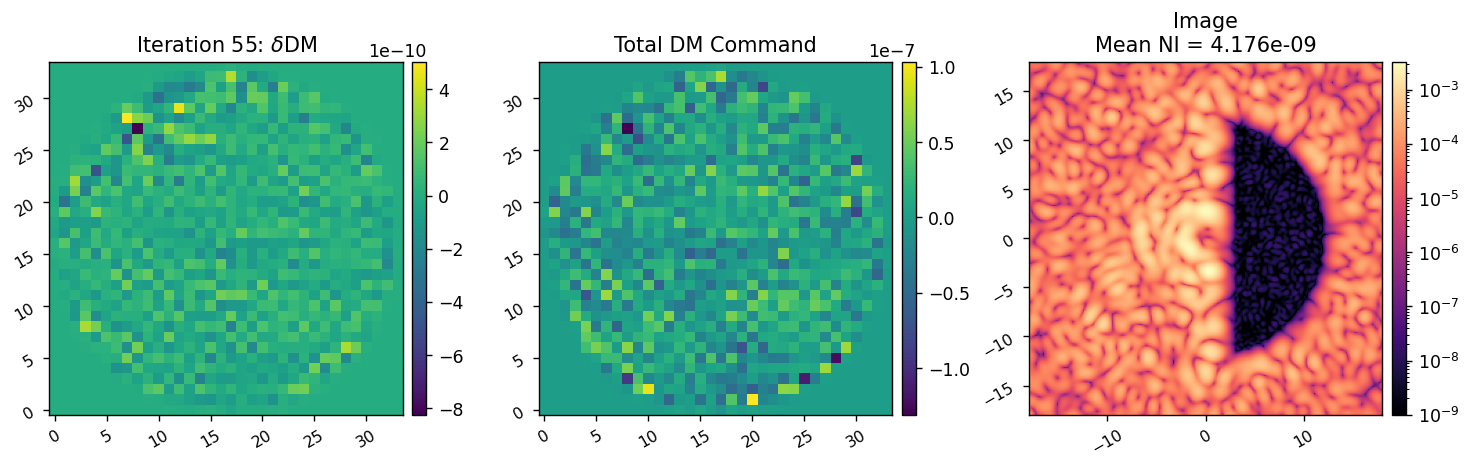

	Closed-loop iteration 56 / 57
Using model to compute electric field


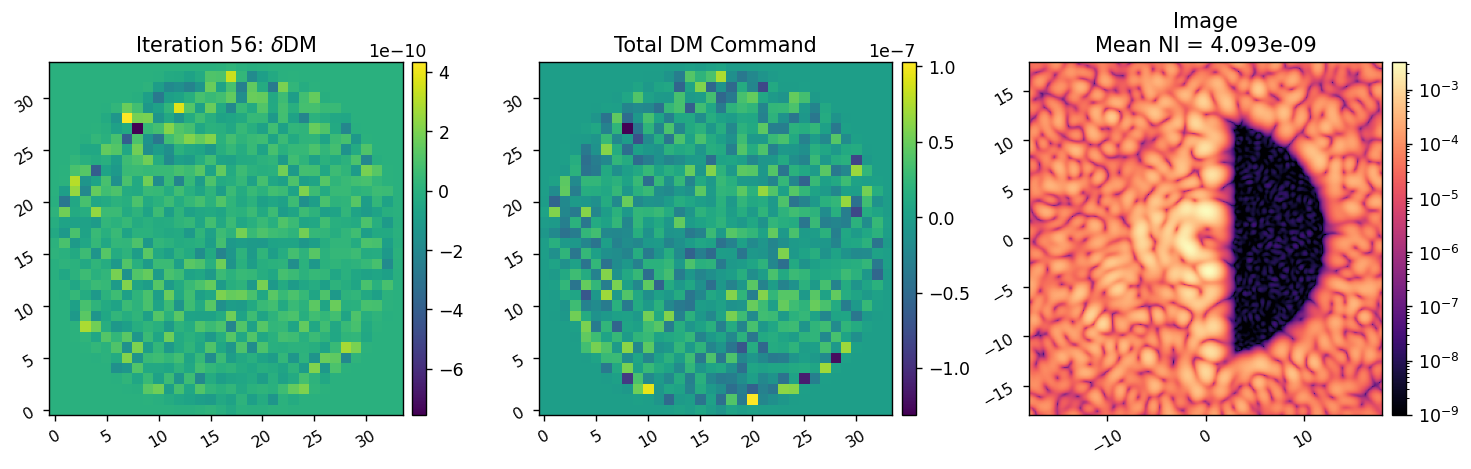

	Closed-loop iteration 57 / 57
Using model to compute electric field


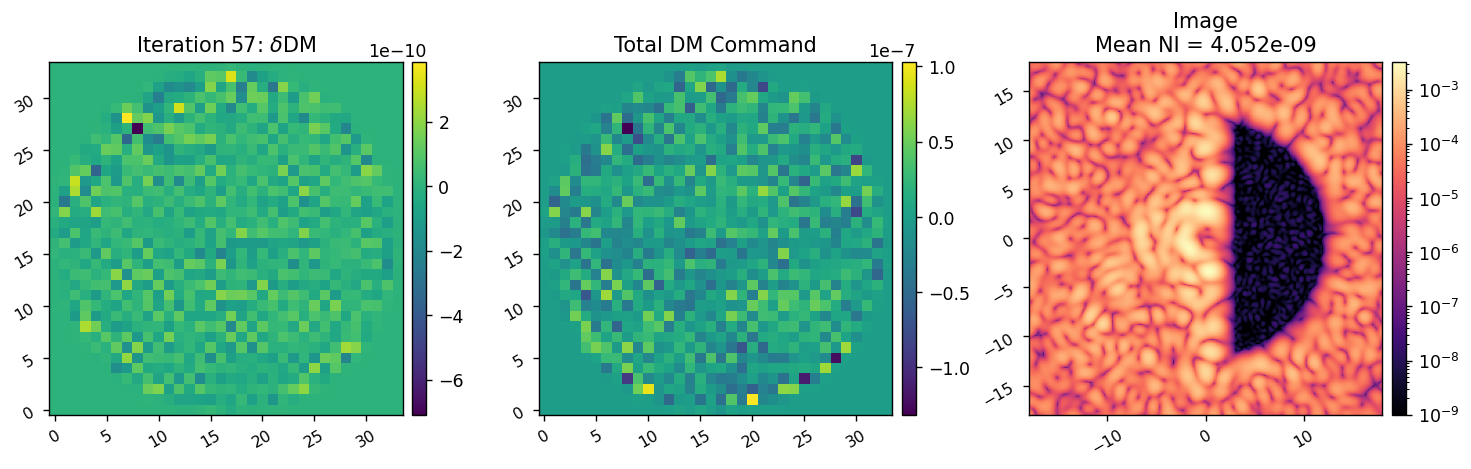

EFC completed in 3.862 sec.


In [112]:
reload(lina.efc)

control_matrix = lina.utils.beta_reg(jac_2, -1.5)
control_matrix = lina.utils.beta_reg(jac_2, -2.5)
control_matrix = lina.utils.beta_reg(jac_2, -3.5)
# control_matrix = lina.utils.beta_reg(jac_2, -5)

images, fields, dm_commands = lina.efc.run(M,
                                            control_matrix,
                                            poke_modes,
                                            control_mask, 
                                            # est_fun=est_fun,
                                            # est_params=est_params,
                                            loop_gain=0.5, 
                                            leakage=0.0,
                                            iterations=3, 
                                            plot_all=True, 
                                            plot_sms=False,
                                            plot_radial_contrast=False,
                                            all_ims=all_ims,
                                            all_efs=all_efs,
                                            all_commands=all_commands,
                                            )

Calculating Jacobian: 
	Calculated response for mode 952/952. Elapsed time=607.039 sec.
Jacobian built in 607.039 sec


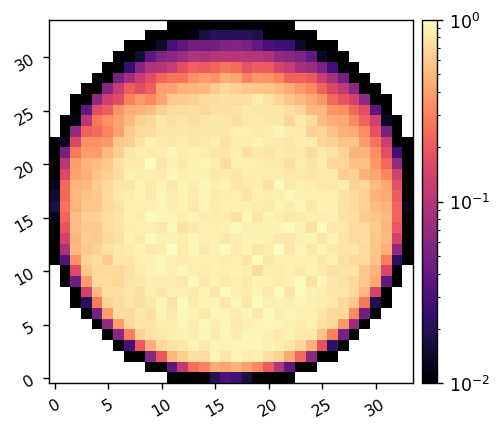

In [113]:
reload(lina.efc)
jac_3, response_cube_3 = lina.efc.calibrate(M,
                                            poke_modes,
                                            #  poke_modes[800:951], 
                                            poke_amp,
                                            control_mask, 
                                            plot=True,
                                            return_all=True,
                                            )

Beginning closed-loop EFC.
	Closed-loop iteration 82 / 84
Using model to compute electric field


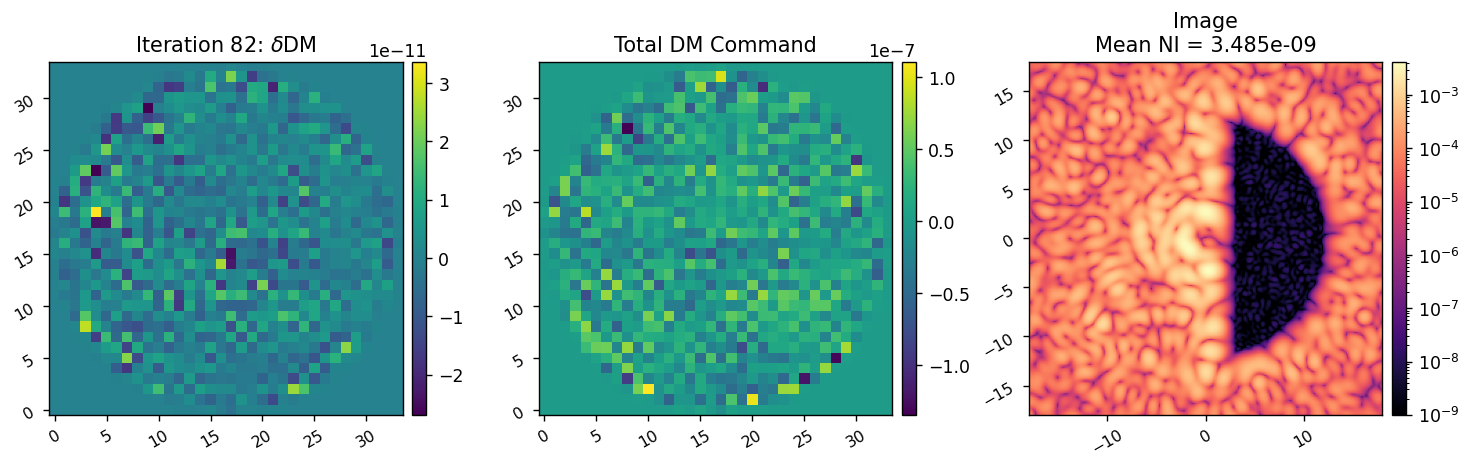

	Closed-loop iteration 83 / 84
Using model to compute electric field


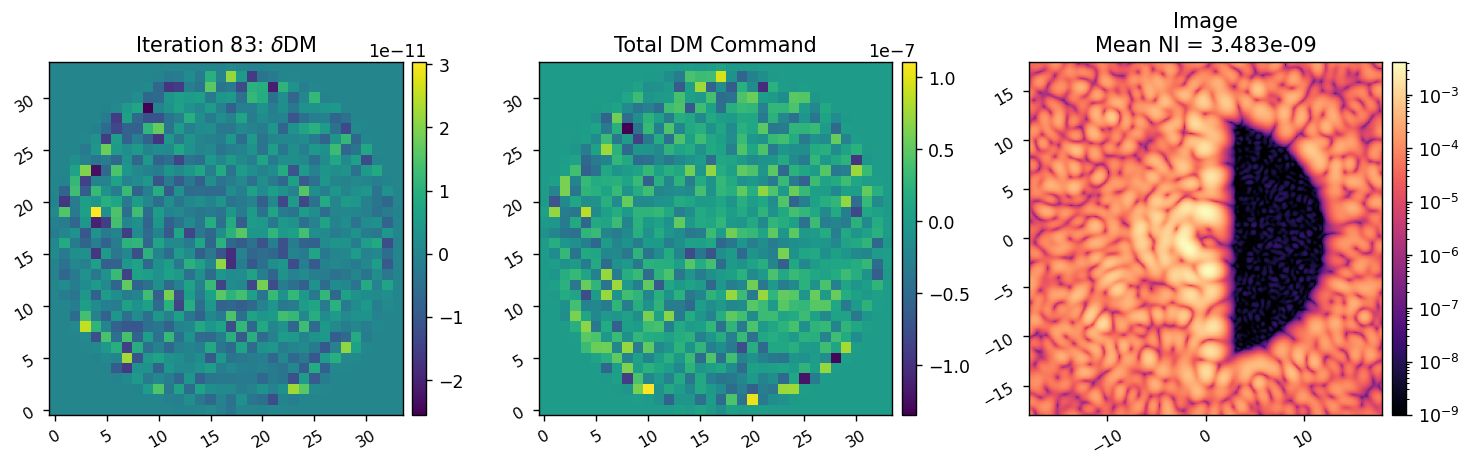

	Closed-loop iteration 84 / 84
Using model to compute electric field


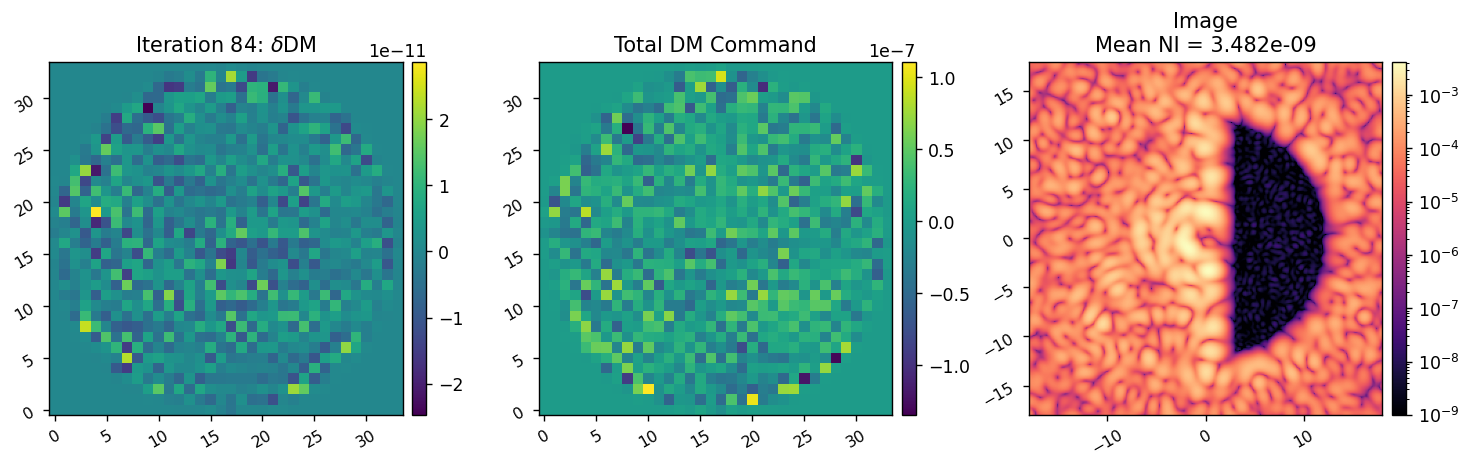

EFC completed in 3.926 sec.


In [122]:
reload(lina.efc)

control_matrix = lina.utils.beta_reg(jac_3, -1.5)
control_matrix = lina.utils.beta_reg(jac_3, -2.5)
# control_matrix = lina.utils.beta_reg(jac_3, -3.5)
# control_matrix = lina.utils.beta_reg(jac_3, -5)

images, fields, dm_commands = lina.efc.run(M,
                                            control_matrix,
                                            poke_modes,
                                            control_mask, 
                                            # est_fun=est_fun,
                                            # est_params=est_params,
                                            loop_gain=0.5, 
                                            leakage=0.0,
                                            iterations=3, 
                                            plot_all=True, 
                                            plot_sms=False,
                                            plot_radial_contrast=False,
                                            all_ims=all_ims,
                                            all_efs=all_efs,
                                            all_commands=all_commands,
                                            )

In [125]:
Nwaves = 5
bw = 0.05
waves = np.linspace(M.wavelength_c * (1-bw/2), M.wavelength_c * (1+bw/2), Nwaves)
waves

<Quantity [6.33750e-07, 6.41875e-07, 6.50000e-07, 6.58125e-07, 6.66250e-07] m>

In [130]:
mono_ims = xp.zeros((Nwaves, M.npsf, M.npsf))
for i in range(Nwaves):
    M.wavelength = waves[i]
    mono_ims[i] = M.snap()
bbim = mono_ims.mean(axis=0)

2.6348602616198465e-08


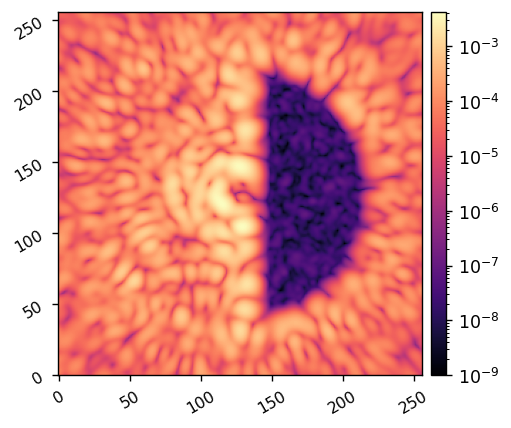

In [132]:
print(xp.mean(bbim[control_mask]))
imshow1(bbim, lognorm=True, vmin=1e-9)


In [123]:
utils.save_fits(f'../data/{today}_esc_fresnel_dh_commands_0.fits', xp.array(all_commands))

Saved data to:  ../data/20240930_esc_fresnel_dh_commands_0.fits
